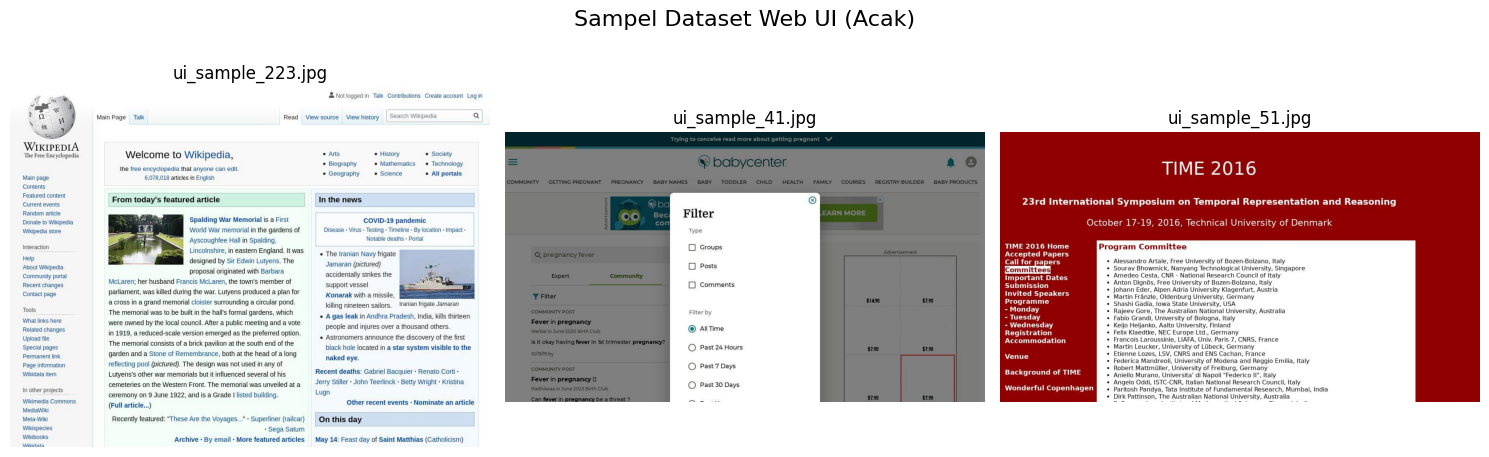

In [83]:
import os
import random  # <-- Tambahan baru
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Menampilkan 3 Sampel Gambar Desain UI secara ACAK
raw_folder = '../data/raw'

# Ambil semua daftar file berakhiran .jpg
all_images = [f for f in os.listdir(raw_folder) if f.endswith('.jpg')]

# Pilih 3 gambar secara acak dari total daftar file
image_files = random.sample(all_images, 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img_file in zip(axes, image_files):
    img_path = os.path.join(raw_folder, img_file)
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(img_file)
    ax.axis('off')
    
plt.suptitle("Sampel Dataset Web UI (Acak)", fontsize=16)
plt.tight_layout()
plt.show()

Menganalisis 500 gambar mentah...


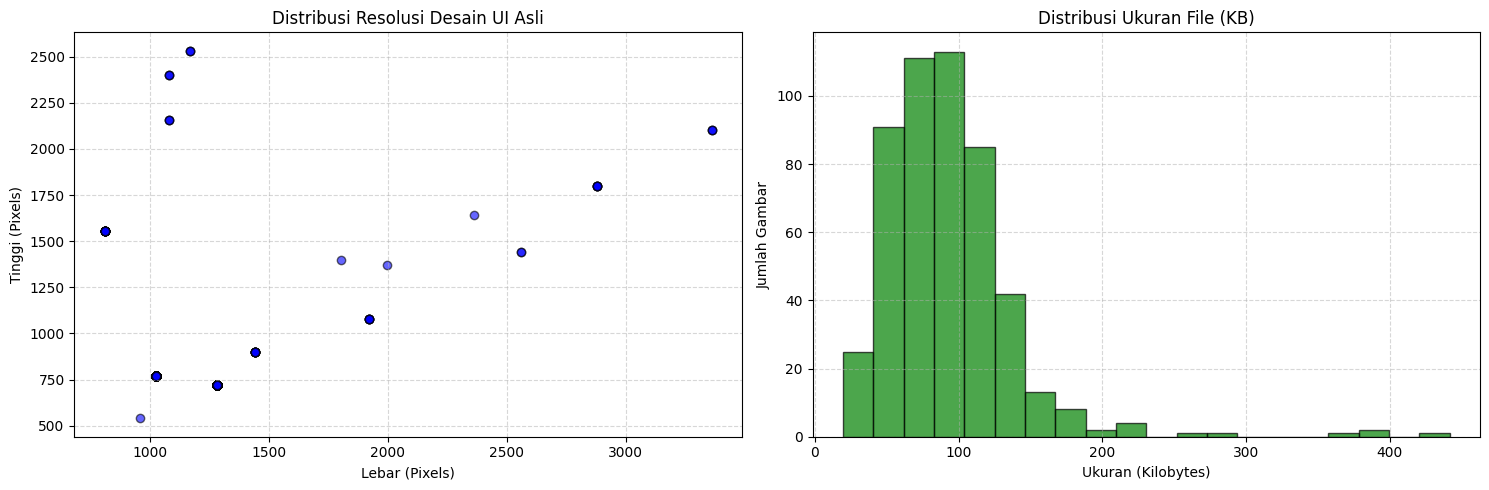

In [84]:
import os
import hashlib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

raw_folder = '../data/raw' # Gunakan ../ karena notebook sekarang ada di dalam folder notebooks/

# Siapkan penampung data
widths = []
heights = []
file_sizes_kb = []
hashes = {} # Untuk mencari duplikat nanti
duplicates = []

image_files = [f for f in os.listdir(raw_folder) if f.endswith('.jpg')]

print(f"Menganalisis {len(image_files)} gambar mentah...")

for filename in image_files:
    filepath = os.path.join(raw_folder, filename)
    
    # 1. Analisis Ukuran File (KB)
    size_kb = os.path.getsize(filepath) / 1024
    file_sizes_kb.append(size_kb)
    
    # 2. Analisis Dimensi (Lebar x Tinggi)
    with Image.open(filepath) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)
        
    # 3. Analisis Duplikat (Membuat Sidik Jari/Hash dari gambar)
    with open(filepath, 'rb') as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
        if file_hash in hashes:
            duplicates.append((filename, hashes[file_hash]))
        else:
            hashes[file_hash] = filename

# --- VISUALISASI DIMENSI & UKURAN FILE ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Sebaran Dimensi Gambar
ax1.scatter(widths, heights, alpha=0.6, c='blue', edgecolors='black')
ax1.set_title('Distribusi Resolusi Desain UI Asli')
ax1.set_xlabel('Lebar (Pixels)')
ax1.set_ylabel('Tinggi (Pixels)')
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot 2: Distribusi Ukuran File
ax2.hist(file_sizes_kb, bins=20, color='green', edgecolor='black', alpha=0.7)
ax2.set_title('Distribusi Ukuran File (KB)')
ax2.set_xlabel('Ukuran (Kilobytes)')
ax2.set_ylabel('Jumlah Gambar')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [85]:
# --- CETAK LAPORAN EDA ---
print("="*40)
print("📊 LAPORAN EKSPLORASI DATA MENTAH")
print("="*40)
print(f"Total Gambar Dianalisis : {len(image_files)} file")
print(f"Rata-rata Resolusi      : {int(np.mean(widths))} x {int(np.mean(heights))} pixels")
print(f"Resolusi Terbesar       : {max(widths)} x {max(heights)} pixels")
print(f"Resolusi Terkecil       : {min(widths)} x {min(heights)} pixels")
print(f"Rata-rata Ukuran File   : {np.mean(file_sizes_kb):.2f} KB")

print("-" * 40)
print(f"🔍 DETEKSI DUPLIKASI DATA")
print("-" * 40)
if len(duplicates) == 0:
    print("✅ STATUS: SANGAT BERSIH!")
    print("Tidak ditemukan gambar kembar (duplikat) di dalam dataset.")
else:
    print(f"⚠️ STATUS: DITEMUKAN {len(duplicates)} DUPLIKAT!")
    for dup in duplicates:
        print(f" - {dup[0]} adalah salinan dari {dup[1]}")
        
print("="*40)
print("Kesimpulan: Data siap untuk tahap Preprocessing (Resizing ke 150x150 dan Filtering).")

📊 LAPORAN EKSPLORASI DATA MENTAH
Total Gambar Dianalisis : 500 file
Rata-rata Resolusi      : 1206 x 834 pixels
Resolusi Terbesar       : 3360 x 2532 pixels
Resolusi Terkecil       : 810 x 540 pixels
Rata-rata Ukuran File   : 92.38 KB
----------------------------------------
🔍 DETEKSI DUPLIKASI DATA
----------------------------------------
⚠️ STATUS: DITEMUKAN 42 DUPLIKAT!
 - ui_sample_182.jpg adalah salinan dari ui_sample_178.jpg
 - ui_sample_185.jpg adalah salinan dari ui_sample_122.jpg
 - ui_sample_209.jpg adalah salinan dari ui_sample_144.jpg
 - ui_sample_224.jpg adalah salinan dari ui_sample_129.jpg
 - ui_sample_244.jpg adalah salinan dari ui_sample_196.jpg
 - ui_sample_252.jpg adalah salinan dari ui_sample_139.jpg
 - ui_sample_26.jpg adalah salinan dari ui_sample_139.jpg
 - ui_sample_266.jpg adalah salinan dari ui_sample_118.jpg
 - ui_sample_280.jpg adalah salinan dari ui_sample_131.jpg
 - ui_sample_299.jpg adalah salinan dari ui_sample_102.jpg
 - ui_sample_313.jpg adalah salinan

In [86]:
import os
import hashlib
import numpy as np
from PIL import Image

processed_folder = '../data/processed'

# Penampung data
p_widths = []
p_heights = []
p_file_sizes_kb = [] # <-- Tambahan baru: Wadah untuk menyimpan ukuran file
p_hashes = set()
p_duplicates = 0

processed_files = [f for f in os.listdir(processed_folder) if f.endswith('.jpg')]

print(f"Menganalisis {len(processed_files)} gambar BERSIH dari folder data/processed...")

for filename in processed_files:
    filepath = os.path.join(processed_folder, filename)
    
    # 1. Cek Ukuran File dalam KB (Tambahan Baru)
    size_kb = os.path.getsize(filepath) / 1024
    p_file_sizes_kb.append(size_kb)
    
    # 2. Cek Dimensi (Membuktikan Resizing berhasil)
    with Image.open(filepath) as img:
        w, h = img.size
        p_widths.append(w)
        p_heights.append(h)
        
    # 3. Cek Duplikat (Membuktikan Cleaning berhasil)
    with open(filepath, 'rb') as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
        if file_hash in p_hashes:
            p_duplicates += 1
        else:
            p_hashes.add(file_hash)

# --- CETAK LAPORAN VERIFIKASI POST-PROCESSING ---
print("\n" + "="*50)
print("✨ LAPORAN VERIFIKASI DATA BERSIH (PROCESSED)")
print("="*50)
print(f"Total Gambar Tersedia   : {len(processed_files)} file")
print(f"Rata-rata Resolusi      : {int(np.mean(p_widths))} x {int(np.mean(p_heights))} pixels")
print(f"Sebaran Resolusi        : Min {min(p_widths)}x{min(p_heights)} | Max {max(p_widths)}x{max(p_heights)}")
print(f"Jumlah Duplikat         : {p_duplicates} file")
print("-" * 50)
print(f"📉 Rata-rata Ukuran File: {np.mean(p_file_sizes_kb):.2f} KB (Data Mentah: 92.45 KB)")
print(f"💾 Total Ukuran Folder  : {sum(p_file_sizes_kb)/1024:.2f} MB")
print("="*50)

# Pengecekan Kualitas Otomatis
if min(p_widths) == 150 and max(p_widths) == 150 and p_duplicates == 0:
    print("\n✅ KESIMPULAN: Pipeline Preprocessing bekerja SEMPURNA!")
    print("Semua data telah seragam (150x150) dan 100% bebas dari duplikasi.")
    print("Beban komputasi berhasil dipangkas secara drastis.")

Menganalisis 458 gambar BERSIH dari folder data/processed...

✨ LAPORAN VERIFIKASI DATA BERSIH (PROCESSED)
Total Gambar Tersedia   : 458 file
Rata-rata Resolusi      : 150 x 150 pixels
Sebaran Resolusi        : Min 150x150 | Max 150x150
Jumlah Duplikat         : 0 file
--------------------------------------------------
📉 Rata-rata Ukuran File: 4.54 KB (Data Mentah: 92.45 KB)
💾 Total Ukuran Folder  : 2.03 MB

✅ KESIMPULAN: Pipeline Preprocessing bekerja SEMPURNA!
Semua data telah seragam (150x150) dan 100% bebas dari duplikasi.
Beban komputasi berhasil dipangkas secara drastis.


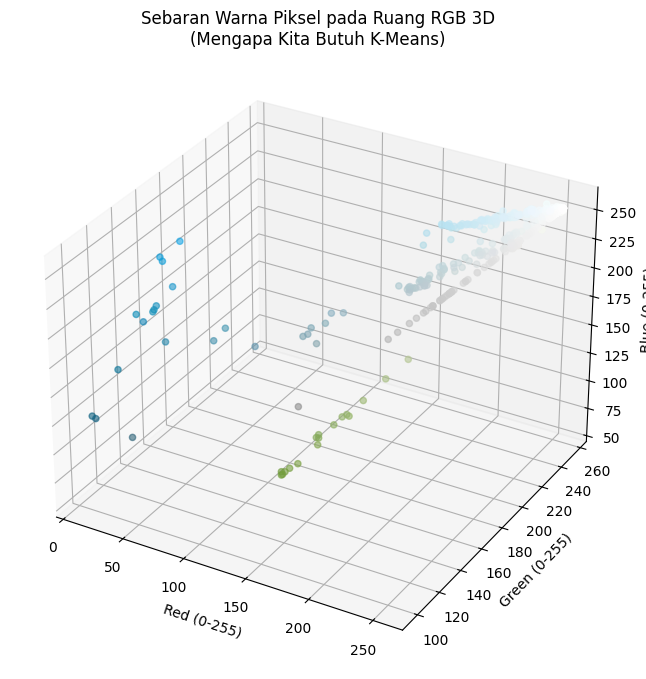

In [87]:
# 2. Membedah Distribusi Warna (RGB 3D Scatter Plot)
# Kita ambil gambar pertama sebagai kelinci percobaan
sample_img_path = os.path.join(raw_folder, image_files[0])

# Perkecil gambar agar laptop tidak nge-lag saat memproses jutaan piksel
img = Image.open(sample_img_path).resize((100, 100))
img_array = np.array(img)

# Ubah matriks gambar (100x100x3) menjadi daftar piksel (10000x3)
pixels = img_array.reshape(-1, 3)

# Kita ambil 1000 piksel acak untuk diplot di ruang 3D
np.random.shuffle(pixels)
sample_pixels = pixels[:1000]

r = sample_pixels[:, 0]
g = sample_pixels[:, 1]
b = sample_pixels[:, 2]

# Normalisasi warna RGB (0-255) menjadi (0-1) untuk format warna matplotlib
colors = sample_pixels / 255.0

# Membuat plot 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot titik-titik warna
ax.scatter(r, g, b, c=colors, marker='o', s=20, alpha=0.6)

ax.set_xlabel('Red (0-255)')
ax.set_ylabel('Green (0-255)')
ax.set_zlabel('Blue (0-255)')
ax.set_title('Sebaran Warna Piksel pada Ruang RGB 3D\n(Mengapa Kita Butuh K-Means)')

plt.show()

Memulai proses K-Means Clustering (Mencari 5 warna dominan)...


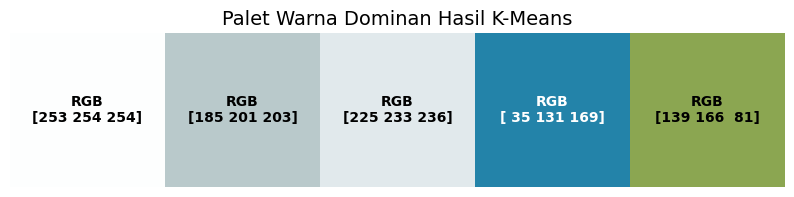

In [88]:
from sklearn.cluster import KMeans
import matplotlib.patches as patches

# 1. Siapkan data piksel dari gambar sampel tadi
# Kita batasi jumlah piksel yang diproses agar komputasi K-Means lebih cepat
pixels_subset = pixels[np.random.choice(pixels.shape[0], 5000, replace=False)]

print("Memulai proses K-Means Clustering (Mencari 5 warna dominan)...")
# 2. Inisialisasi dan jalankan algoritma K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(pixels_subset)

# 3. Ambil titik tengah (centroid) sebagai warna dominan
dominant_colors = kmeans.cluster_centers_.astype(int)

# 4. Visualisasikan Palet Warna
fig, ax = plt.subplots(figsize=(10, 2))
for i, color in enumerate(dominant_colors):
    # Buat kotak warna untuk setiap warna dominan
    rect = patches.Rectangle((i, 0), 1, 1, facecolor=color/255.0)
    ax.add_patch(rect)
    
    # Tulis kode RGB di atas warna tersebut
    plt.text(i + 0.5, 0.5, f"RGB\n{color}", ha='center', va='center', 
             color='white' if np.mean(color) < 128 else 'black', fontweight='bold')

ax.set_xlim(0, len(dominant_colors))
ax.set_ylim(0, 1)
ax.axis('off')
plt.title("Palet Warna Dominan Hasil K-Means", fontsize=14)
plt.show()

In [89]:
# Fungsi untuk menghitung Luminance Relatif sesuai standar WCAG 2.1
def get_luminance(rgb):
    r, g, b = [x / 255.0 for x in rgb]
    r = r / 12.92 if r <= 0.03928 else ((r + 0.055) / 1.055) ** 2.4
    g = g / 12.92 if g <= 0.03928 else ((g + 0.055) / 1.055) ** 2.4
    b = b / 12.92 if b <= 0.03928 else ((b + 0.055) / 1.055) ** 2.4
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

# Fungsi untuk menghitung Rasio Kontras
def get_contrast_ratio(color1, color2):
    lum1 = get_luminance(color1)
    lum2 = get_luminance(color2)
    lighter = max(lum1, lum2)
    darker = min(lum1, lum2)
    return (lighter + 0.05) / (darker + 0.05)

print("--- Hasil Uji Kontras WCAG 2.1 (Standar Minimal 4.5:1) ---\n")

# Mari kita uji setiap kombinasi warna dari palet yang dihasilkan K-Means
for i in range(len(dominant_colors)):
    for j in range(i + 1, len(dominant_colors)):
        c1, c2 = dominant_colors[i], dominant_colors[j]
        ratio = get_contrast_ratio(c1, c2)
        
        status = "✅ LULUS" if ratio >= 4.5 else "❌ GAGAL"
        print(f"Kombinasi Warna {i+1} & {j+1}: Rasio {ratio:.2f}:1 -> {status}")

--- Hasil Uji Kontras WCAG 2.1 (Standar Minimal 4.5:1) ---

Kombinasi Warna 1 & 2: Rasio 1.69:1 -> ❌ GAGAL
Kombinasi Warna 1 & 3: Rasio 1.22:1 -> ❌ GAGAL
Kombinasi Warna 1 & 4: Rasio 4.25:1 -> ❌ GAGAL
Kombinasi Warna 1 & 5: Rasio 2.71:1 -> ❌ GAGAL
Kombinasi Warna 2 & 3: Rasio 1.39:1 -> ❌ GAGAL
Kombinasi Warna 2 & 4: Rasio 2.51:1 -> ❌ GAGAL
Kombinasi Warna 2 & 5: Rasio 1.60:1 -> ❌ GAGAL
Kombinasi Warna 3 & 4: Rasio 3.49:1 -> ❌ GAGAL
Kombinasi Warna 3 & 5: Rasio 2.23:1 -> ❌ GAGAL
Kombinasi Warna 4 & 5: Rasio 1.57:1 -> ❌ GAGAL


In [90]:
import numpy as np

# --- 1. RUMUS LUMINANSI (Kecerahan Relatif) ---
def get_luminance(color):
    # Rumus standar WCAG 2.1 untuk mengubah RGB ke nilai Luminansi
    c = color / 255.0
    c = np.where(c <= 0.03928, c / 12.92, ((c + 0.055) / 1.055) ** 2.4)
    return 0.2126 * c[0] + 0.7152 * c[1] + 0.0722 * c[2]

# --- 2. RUMUS RASIO KONTRAS ---
def get_contrast_ratio(color1, color2):
    l1 = get_luminance(np.array(color1))
    l2 = get_luminance(np.array(color2))
    bright = max(l1, l2)
    dark = min(l1, l2)
    return (bright + 0.05) / (dark + 0.05)

# --- 3. ALGORITMA AUTO-HEAL ---
def auto_heal_contrast(bg_color, fg_color, target_ratio=4.5):
    bg_color = np.array(bg_color, dtype=float)
    fg_color = np.array(fg_color, dtype=float)
    
    # Cek rasio saat ini
    current_ratio = get_contrast_ratio(bg_color, fg_color)
    if current_ratio >= target_ratio:
        return fg_color.astype(int), current_ratio # Sudah lulus, tidak perlu diubah
        
    # Tentukan mana yang harus digelapkan/diterangkan
    bg_lum = get_luminance(bg_color)
    fg_lum = get_luminance(fg_color)
    
    healed_fg = fg_color.copy()
    step = 5 # Kecepatan penyembuhan
    
    # Looping penyembuhan: Geser warna foreground sampai rasionya tembus 4.5
    for _ in range(100): # Maksimal 100 kali percobaan agar tidak infinite loop
        if fg_lum > bg_lum:
            healed_fg = np.clip(healed_fg + step, 0, 255) # Terangkan teks
        else:
            healed_fg = np.clip(healed_fg - step, 0, 255) # Gelapkan teks
            
        new_ratio = get_contrast_ratio(bg_color, healed_fg)
        if new_ratio >= target_ratio:
            return healed_fg.astype(int), new_ratio
            
    return healed_fg.astype(int), get_contrast_ratio(bg_color, healed_fg)

C:\Users\affan\AppData\Local\Temp\ipykernel_6868\3909092455.py:52: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\affan\AppData\Local\Temp\ipykernel_6868\3909092455.py:52: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\#Kuliah\SMT 6\PDM\project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\#Kuliah\SMT 6\PDM\project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


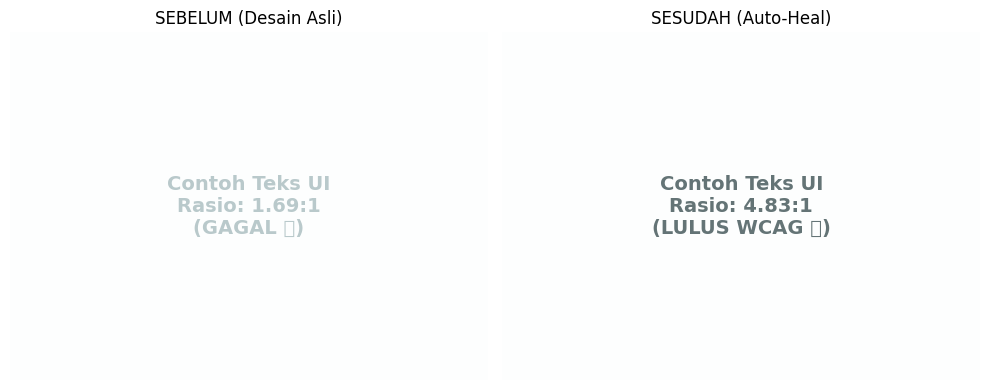

In [91]:
# --- MARI KITA UJI COBA SIMULASINYA (VERSI CERDAS) ---

warna_background = None
warna_foreground = None
rasio_asli = 0

# 1. Cari secara spesifik kombinasi warna yang GAGAL (< 4.5) untuk di-heal
for i in range(len(dominant_colors)):
    for j in range(i + 1, len(dominant_colors)):
        c1, c2 = dominant_colors[i], dominant_colors[j]
        ratio = get_contrast_ratio(c1, c2)
        
        if ratio < 4.5:
            warna_background = c1
            warna_foreground = c2
            rasio_asli = ratio
            break # Berhenti mencari jika sudah menemukan yang gagal
    if warna_background is not None:
        break

# Jika secara ajaib semua warna di desain itu lulus WCAG alami:
if warna_background is None:
    print("Wah! Semua kombinasi palet dari gambar ini sudah lulus WCAG secara alami.")
    warna_background, warna_foreground = dominant_colors[0], dominant_colors[1]
    rasio_asli = get_contrast_ratio(warna_background, warna_foreground)

# 2. Jalankan mesin penyembuh!
healed_color, rasio_baru = auto_heal_contrast(warna_background, warna_foreground)

# 3. Label Dinamis
status_asli = "LULUS ✅" if rasio_asli >= 4.5 else "GAGAL ❌"

# 4. Visualisasikan Hasil
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Kotak Sebelum
rect1 = patches.Rectangle((0, 0), 1, 1, facecolor=warna_background/255.0)
axes[0].add_patch(rect1)
axes[0].text(0.5, 0.5, f"Contoh Teks UI\nRasio: {rasio_asli:.2f}:1\n({status_asli})", 
             ha='center', va='center', fontsize=14, fontweight='bold', color=warna_foreground/255.0)
axes[0].axis('off')
axes[0].set_title("SEBELUM (Desain Asli)")

# Kotak Sesudah (Auto-Heal)
rect2 = patches.Rectangle((0, 0), 1, 1, facecolor=warna_background/255.0)
axes[1].add_patch(rect2)
axes[1].text(0.5, 0.5, f"Contoh Teks UI\nRasio: {rasio_baru:.2f}:1\n(LULUS WCAG ✅)", 
             ha='center', va='center', fontsize=14, fontweight='bold', color=np.array(healed_color)/255.0)
axes[1].axis('off')
axes[1].set_title("SESUDAH (Auto-Heal)")

plt.tight_layout()
plt.show()